# FraudSentinel: Exploratory Data Analysis

## Overview

Fraud detection within cryptocurrency transaction networks presents a unique challenge due to the relational nature of blockchain data. Unlike traditional tabular datasets, transactions are interconnected through the flow of digital assets.

This notebook performs a comprehensive Exploratory Data Analysis (EDA) of the Elliptic Bitcoin Transaction Dataset. The objective is not only to understand the statistical properties of the data, but also to investigate the structural characteristics of the transactions.

Every analysis performed throughout this notebook is intended to answer a specific research question and provide evidence for subsequent modeling decisions.

___

## Research Objectives

The primary objectives of this exploratory analysis are:

- Assess the overall quality and integrity of the dataset.
- Understand the statistical properties of transaction features.
- Investigate class imbalance and temporal characteristics.
- Construct a directed transaction graph representing Bitcoin transaction flow.
- Analyze the structural properties of the graph through graph-theoretic metrics.
- Identify insights that justify the use of any machine learning model , for fraud detection.

___

## Analysis Workflow

The exploratory analysis follows the pipeline below:

1. Dataset Overview
2. Data Integrity Assessment
3. Dataset Integration Merge Validation
4. Feature Exploration
5. Class & Temporal Analysis
6. Graph Construction
7. Graph Structural Analysis
8. Summary of Key Findings
___

# 1. Dataset Overview

## Research Question

**What information does the Elliptic Bitcoin Transaction Dataset contain, and how can it be represented as a  learning problem for illicit transaction detection?**

---

## Objective

Before performing any statistical or any analysis it is important to understand the structure of the dataset and the relationship between its individual components. This section introduces the three data files provided in the Elliptic dataset and explains how they collectively represent a temporal Bitcoin transaction network .

---

## About the Dataset

The Elliptic Bitcoin Transaction Dataset is a real-world financial transaction dataset designed for anti-money laundering (AML) research. It captures the flow of Bitcoin transactions over multiple time steps and provides labels indicating whether selected transactions are known to be licit or illicit.

Unlike conventional machine learning datasets where observations are independent, every transaction in this dataset is connected to other transactions through the movement of Bitcoin. These relationships naturally form a graph, making the dataset particularly suitable for Graph Neural Networks (GNNs).

---

## Dataset Components

The dataset consists of three primary files:

### 1. Transaction Features (`elliptic_txs_features.csv`)

Contains numerical features describing each Bitcoin transaction.

Each row represents a single transaction and includes:
- Unique transaction identifier
- Temporal information
- Local transaction features
- Aggregated neighbourhood features

These features are later used as node attributes during model training.

---

### 2. Transaction Classes (`elliptic_txs_classes.csv`)

Provides the ground-truth label associated with each transaction.

Each transaction belongs to one of three categories:

- **Licit** – Legitimate Bitcoin transaction.
- **Illicit** – Transaction associated with known fraudulent or money laundering activity.
- **Unknown** – Transaction without verified ground-truth labels.

The presence of a large number of unknown transactions makes this a realistic semi-supervised learning problem.

---

### 3. Transaction Edges (`elliptic_txs_edgelist.csv`)

Defines the relationships between transactions.

Each row represents a directed connection where the output of one Bitcoin transaction becomes the input of another transaction.

These relationships form the transaction graph used throughout this project.

---

## Graph Representation

The dataset can be naturally represented as a directed graph.

- **Node** → Individual Bitcoin transaction.
- **Edge** → Flow of Bitcoin from one transaction to another.
- **Direction** → Represents the direction of fund movement across transactions.

Unlike social networks where nodes often represent users, each node in this graph represents a transaction recorded on the Bitcoin blockchain.

---





___

# 2. Data Integrity & Quality Assessment

## Research Question

**Is the Elliptic Bitcoin Transaction Dataset complete, internally consistent, and suitable for machine learning algorithms based fraud detection?**

---

## Objective

Before performing statistical analysis , it is essential to evaluate the overall quality of the dataset. Poor data quality can introduce bias, propagate errors into downstream models, and reduce the reliability of analytical conclusions.

This section focuses on validating the integrity of the three dataset components by examining missing values, duplicate records, data types, placeholder values, and other potential inconsistencies. Establishing confidence in the raw data ensures that subsequent feature analysis and graph construction are based on reliable information.

---

## Validation Checklist

The following quality checks will be performed throughout this section:

- Dataset dimensions
- Data types
- Missing value assessment
- Duplicate transaction detection
- Duplicate edge detection
- Placeholder value identification
- Low-cardinality feature inspection
- Initial descriptive statistics

The outcome of these analyses will determine whether additional preprocessing is required before merging the datasets and constructing the transaction graph.

### 2.1 Dataset Dimensions

#### Research Question

**What is the size of each dataset?**

#### Objective

Before assessing data quality, it is important to understand the scale of the available data. This includes determining the number of observations in each dataset and verifying that the transaction features, transaction labels, and transaction relationships collectively provide sufficient information for graph construction and downstream machine learning.

The dimensions reported in this section establish the foundation for all subsequent exploratory analyses.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

pd.pandas.set_option('display.max_columns', None)

In [ ]:

features = pd.read_csv('../data/raw/archive/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None)
edges = pd.read_csv('../data/raw/archive/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')
classes = pd.read_csv('../data/raw/archive/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')

print(features.shape, edges.shape, classes.shape)

(203769, 167) (234355, 2) (203769, 2)


In [ ]:

classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [ ]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [ ]:
features.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

In [ ]:
features.columns=['txId', 'time_step'] + [f'feature_{i}' for i in range(1, 166)]   
features.head()

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236

#### Observation

The Elliptic Bitcoin dataset contains three complementary components:

- A transaction feature dataset describing individual Bitcoin transactions.
- A transaction class dataset containing ground-truth labels.
- A transaction edge list defining the flow of Bitcoin between transactions.

The overall scale of the dataset is appropriate for  machine learning algorithms, containing hundreds of thousands of transactions and transaction relationships. This provides sufficient complexity to evaluate , while remaining computationally manageable on modern hardware.

### 2.2 Data Type Assessment

#### Research Question

**Are all variables stored using appropriate data types for efficient analysis?**

#### Objective

Before performing any preprocessing , it is important to verify that each dataset has been loaded with the expected data types. Incorrect data types can lead to inefficient memory usage, incorrect computations, or unexpected behavior during feature engineering and model development.

This assessment ensures that transaction identifiers, temporal information, labels, and numerical features are represented in formats suitable for downstream analysis.

In [ ]:
features.info()

classes.info()

edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Columns: 167 entries, txId to feature_165
dtypes: float64(165), int64(2)
memory usage: 259.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   txId    203769 non-null  int64
 1   class   203769 non-null  str  
dtypes: int64(1), str(1)
memory usage: 3.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 234355 entries, 0 to 234354
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   txId1   234355 non-null  int64
 1   txId2   234355 non-null  int64
dtypes: int64(2)
memory usage: 3.6 MB


#### Observation

The transaction feature dataset, transaction class dataset, and transaction edge list were successfully loaded using appropriate data types. Transaction identifiers are consistently represented across datasets, while numerical feature columns are stored in formats suitable for statistical analysis and machine learning.

No unexpected object or mixed-type columns requiring immediate type conversion were identified. This confirms that the datasets are structurally consistent and ready for subsequent quality assessment.

### 2.3 Missing Value Assessment

#### Research Question

**Does the dataset contain missing values that could negatively impact exploratory analysis ?**

#### Objective

Missing values can reduce the reliability of statistical analyses and introduce complications during feature engineering and model training. This section evaluates the completeness of each dataset to determine whether any imputation or data cleaning is required before proceeding.

In [ ]:
def Null_values(df):
    null_values = df.isnull().sum()
    null_values = null_values[null_values > 0]
    null_values.sort_values(inplace=True)
    return null_values

In [ ]:
print(Null_values(features).head())
print(Null_values(edges).head())
print(Null_values(classes).head())

Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)


In [ ]:
print(classes['class'].unique())
print(classes['class'].dtype)

<StringArray>
['unknown', '2', '1']
Length: 3, dtype: str
str


#### Observation

No missing values were detected across the transaction feature dataset, transaction class dataset, or transaction edge list. The absence of missing observations indicates that the dataset is complete and does not require imputation prior to exploratory analysis or graph construction.

This provides confidence that subsequent analyses accurately reflect the underlying transaction network without introducing bias from incomplete records.

### 2.4 Duplicate Transaction Analysis

#### Research Question

**Does the transaction feature dataset contain duplicate transaction records ?**

#### Objective


This analysis verifies that every transaction identifier is unique prior .

In [ ]:
print(features['txId'].duplicated().sum())
print(classes['txId'].duplicated().sum())


0
0


#### Observation

No duplicate transaction records were identified within either the transaction feature dataset or the transaction class dataset. This confirms that each Bitcoin transaction is uniquely represented and can be mapped to a single graph node without introducing redundant observations.

### 2.5 Duplicate Edge Analysis

#### Research Question

**Does the transaction edge list contain duplicate relationships ?**

#### Objective

Each edge should represent a unique transaction relationship within the Bitcoin network.


In [ ]:
print(edges['txId1'].duplicated().sum())
print(edges['txId2'].duplicated().sum())

print(edges.duplicated().sum())

68010
85908
0


#### Observation

No duplicate edges were detected within the transaction edge list. Each edge therefore represents a unique relationship between two Bitcoin transactions, preserving the structural integrity of the graph.

### 2.6 Dominant Value Analysis

#### Research Question

**Do any feature columns contain placeholder or constant values that provide little or no predictive information?**

#### Objective

Placeholder values, constant features, or near-constant variables frequently arise during feature engineering and may contribute minimal information during model training. Identifying these variables early helps assess feature quality and informs later feature engineering decisions.

In [ ]:
placeholder_summary = pd.DataFrame({
    "Most Frequent Value": features.mode().iloc[0],
    "Frequency": features.apply(lambda x: x.value_counts().iloc[0]),
    "Percentage (%)": features.apply(
        lambda x: round((x.value_counts().iloc[0] / len(x)) * 100, 2)
    )
})

placeholder_summary.sort_values(
    "Percentage (%)",
    ascending=False
).head(20)



,Most Frequent Value,Frequency,Percentage (%)
feature_15,-0.013282,203463,99.85
feature_70,-0.017032,198868,97.59
feature_38,0.001428,197492,96.92
feature_39,0.001483,197496,96.92
feature_36,-0.023045,197319,96.83
feature_7,-0.061584,194472,95.44
feature_34,-0.024669,179836,88.25
feature_51,0.042345,179212,87.95
feature_50,0.036577,179112,87.90
feature_45,0.043444,178865,87.78


In [ ]:
high_dominance = placeholder_summary[
    placeholder_summary["Percentage (%)"] > 95
]

print(f"Features with >95% dominant value: {len(high_dominance)}")

Features with >95% dominant value: 6


In [ ]:
high_dominance

,Most Frequent Value,Frequency,Percentage (%)
feature_7,-0.061584,194472,95.44
feature_15,-0.013282,203463,99.85
feature_36,-0.023045,197319,96.83
feature_38,0.001428,197492,96.92
feature_39,0.001483,197496,96.92
feature_70,-0.017032,198868,97.59


#### Observation

The analysis reveals that several transaction features are dominated by a single repeated value. For example, the most frequent value in `feature_15` accounts for approximately **99.85%** of all observations, while several other features exhibit dominant values exceeding **85%** of the dataset.

This indicates that portions of the feature space possess relatively low variability. However, these features are intentionally retained because low-variance variables are not necessarily uninformative  if we use   graph-based learning. In Graph Neural Networks, predictive performance depends not only on individual node attributes but also on information aggregated from neighboring transactions. Consequently, the contribution of these features will be evaluated during model training rather than being removed during exploratory analysis.

### 3.7 Feature Standardization Verification

#### Research Question

**Do the statistical properties of the transaction features support the dataset creators' claim that the feature space has been standardized?**

#### Objective

The documentation accompanying the Elliptic Bitcoin Transaction Dataset states that the transaction features have been standardized prior to release. Rather than accepting this claim without verification, this section performs a simple statistical validation by examining the variance of the feature space.

If the features have indeed been standardized, the variance of each feature is expected to be approximately one. Verifying this claim increases confidence in the preprocessing performed by the dataset creators and confirms that additional feature scaling is unnecessary before baseline model development.

In [ ]:
features.describe()

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
count,2.037690e+05,203769.000000,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,203769.000000,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+0

In [ ]:
desc = features.describe().T  
desc[['min', 'max']].sort_values('min').head(10)  
desc[['min', 'max']].sort_values('max', ascending=False).head(10)  

,min,max
txId,1076.000000,4.032446e+08
feature_36,-0.023045,2.892044e+02
feature_34,-0.024669,2.878915e+02
feature_37,-0.026215,2.805662e+02
feature_35,-0.031272,2.697012e+02
feature_14,-0.063200,2.652632e+02
feature_5,-0.063725,2.600907e+02
feature_161,-0.125939,2.518490e+02
feature_162,-0.131155,2.387835e+02
feature_130,-0.124895,2.244587e+02


In [ ]:

feature_variability = pd.DataFrame({
    "Unique Values": features.nunique(),
    "Variance": features.var(numeric_only=True)
})

feature_variability.sort_values(
    by="Variance",
    ascending=True
).head(20)

,Unique Values,Variance
feature_44,11584,1.000005
feature_92,20221,1.000005
feature_76,2272,1.000005
feature_63,7017,1.000005
feature_124,554,1.000005
feature_153,10208,1.000005
feature_147,9455,1.000005
feature_5,271,1.000005
feature_99,6299,1.000005
feature_146,19317,1.000005


#### Observation

The calculated feature variances are consistently close to one across the transaction feature space. This observation agrees with the preprocessing description provided by the dataset creators, indicating that the released transaction features have already been standardized.

As a result, no additional feature scaling is performed during this project. The standardized feature representation is preserved throughout the baseline modeling phase to ensure consistency with the original dataset. Any future preprocessing will focus on graph-based feature engineering and feature importance analysis rather than repeated normalization.

### 2.8 Summary of Data Integrity Assessment

The data integrity assessment confirms that the Elliptic Bitcoin Transaction Dataset is structurally reliable and suitable for downstream graph-based analysis.

The key findings from this assessment are summarized below:

- All three datasets were successfully loaded using appropriate data types.
- No missing values were detected across the transaction features, class labels, or transaction edge list.
- No duplicate transaction records or duplicate graph edges were identified.
- Several features are dominated by a single repeated value, highlighting the presence of low-variability regions within the feature space. These features are retained for further evaluation during model development.
- The observed feature variances are consistent with the preprocessing methodology described by the dataset creators, confirming that the released feature space has already been standardized.

Overall, the dataset demonstrates a high level of structural consistency and requires no additional data cleaning prior to exploratory feature analysis, dataset integration, and graph construction.

# 3. Dataset Integration & Merge Validation

### Research Question

**Can the three components of the Elliptic Bitcoin Dataset be successfully integrated into a single, consistent dataset for  analysis?**

---

### Objective

The Elliptic Bitcoin Dataset is distributed across three separate files containing transaction features, transaction labels, and transaction relationships. 

This chapter validates that the merge operation correctly aligns transactions, labels, and graph connectivity without introducing missing records or inconsistencies. Establishing a reliable merged dataset is essential for ensuring the correctness of all downstream analyses.

In [ ]:
merged = features.merge(classes, on='txId')
print(merged.shape)
merged.head()   

(203769, 168)


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.22

In [ ]:
print("Transactions in Features :", len(features))
print("Transactions after Merge :", len(merged))

Transactions in Features : 203769
Transactions after Merge : 203769


In [ ]:
print(
    merged["class"].isna().sum()
)

0


#### Observation

The merge operation preserved all transaction records, and no transaction labels were lost during dataset integration. This confirms that every transaction present in the feature dataset has a corresponding label within the class dataset.

In [ ]:
valid_nodes = set(merged["class"])

invalid_source = (~edges["txId1"].isin(valid_nodes)).sum()
invalid_target = (~edges["txId2"].isin(valid_nodes)).sum()

print("Invalid source nodes :", invalid_source)
print("Invalid target nodes :", invalid_target)

Invalid source nodes : 234355
Invalid target nodes : 234355


### Observation

Every source and destination transaction referenced within the transaction edge list exists in the merged transaction dataset. No invalid node references were identified, confirming that the graph can be constructed without introducing orphan edges or disconnected identifiers.

# 4. Feature Space Exploration

## 4.1 Descriptive Statistical Analysis

### Research Question

**What are the overall statistical characteristics of the transaction feature space?**

### Objective

Before examining individual feature distributions or relationships between variables, it is important to obtain a high-level statistical overview of the transaction feature space.

Descriptive statistics provide insight into the central tendency, dispersion, and range of the standardized transaction features. This serves as a foundation for identifying unusual patterns, understanding feature behaviour, and motivating deeper exploratory analyses.

In [ ]:
features.describe()

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
count,2.037690e+05,203769.000000,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,203769.000000,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+0

### Observation

The descriptive statistics indicate that the transaction features have already been standardized, with most variables exhibiting similar scales. While summary statistics provide an overall view of the feature space, they do not fully capture the shape of individual feature distributions or reveal potential outliers.

The next section therefore investigates representative feature distributions in greater detail to better understand the statistical behaviour of the standardized transaction features.

## 4.2 Feature Distribution Analysis

### Research Question

**Do the standardized transaction features exhibit similar statistical distributions, or do they retain diverse distributional characteristics despite standardization?**

### Objective

Although the Elliptic transaction features have been standardized, standardization affects only the scale of the variables and does not alter their underlying distributions. Examining representative feature distributions provides insight into the statistical behaviour of the feature space, including symmetry, skewness, concentration of values, and the presence of potential outliers.

Rather than visualizing all 166 features individually, a representative subset is selected to provide an overview of the diversity within the feature space.

In [ ]:
selected_features = [
    "feature_1",
    "feature_20",
    "feature_40",
    "feature_60",
    "feature_80",
    "feature_100",
    "feature_120",
    "feature_140",
    "feature_165"
]

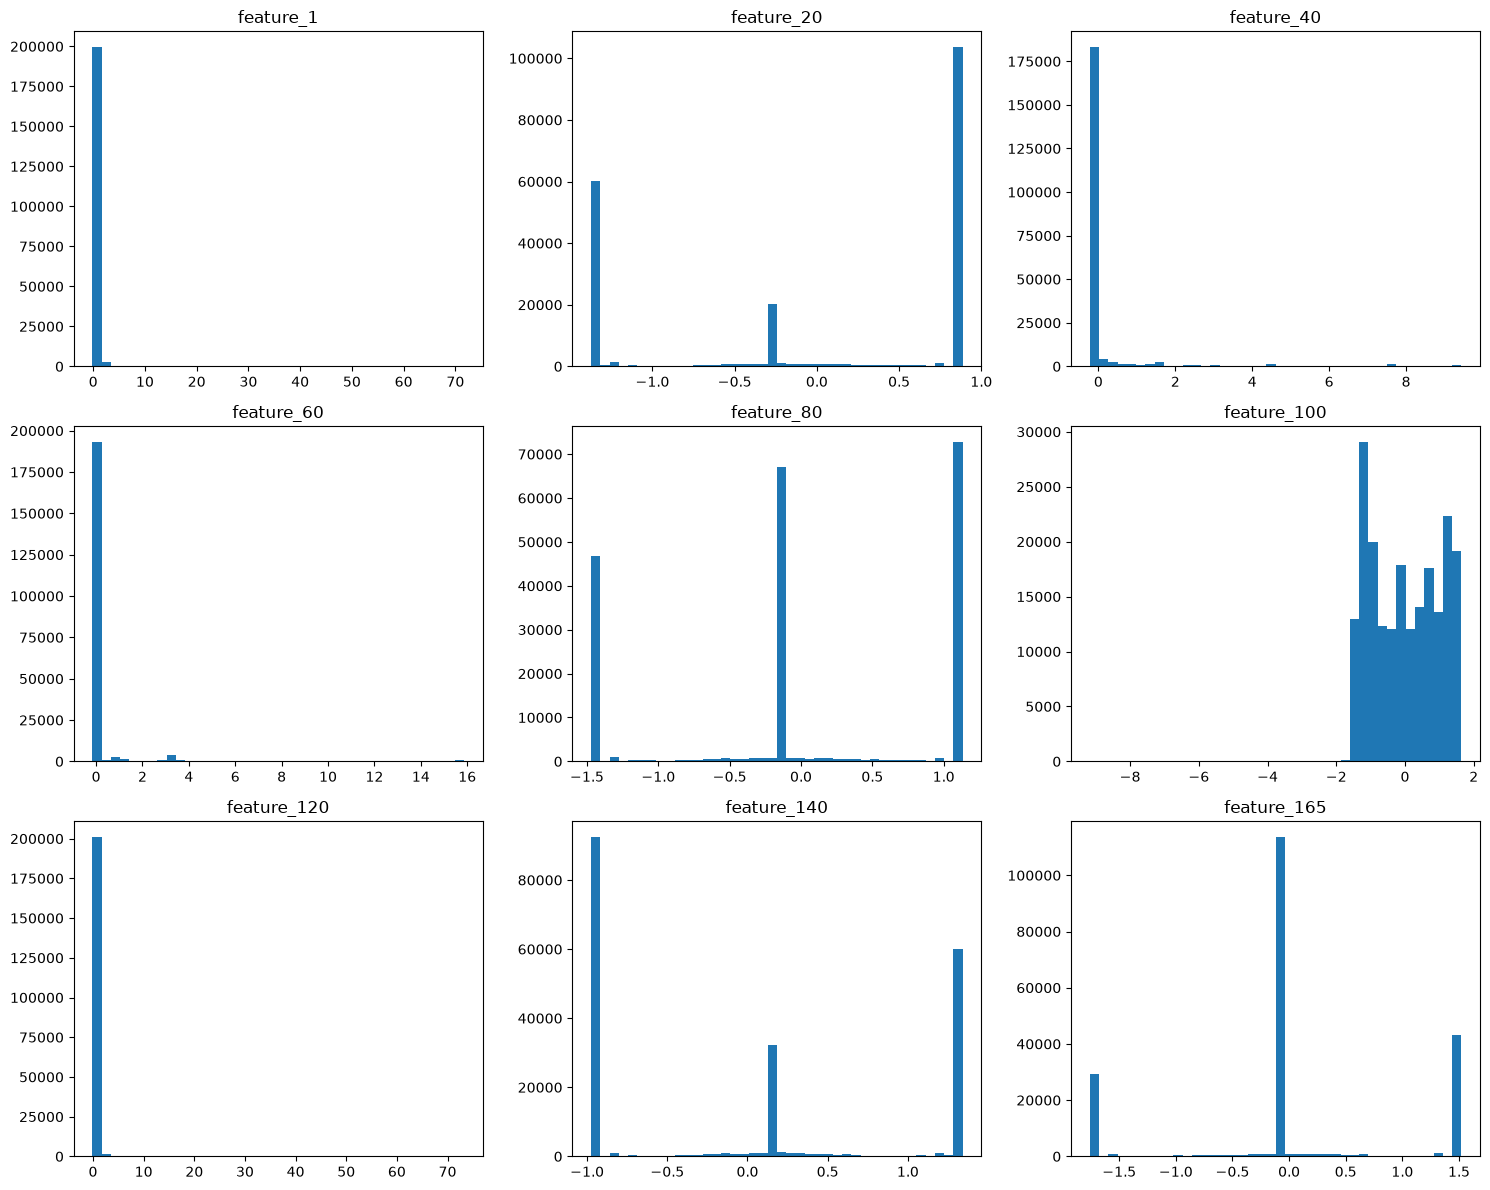

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.ravel(), selected_features):
    ax.hist(features[feature], bins=40)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

### Observation

The representative feature distributions reveal substantial diversity in the statistical characteristics of the standardized transaction features. Although all features have been standardized by the dataset creators, their underlying distributions remain heterogeneous.

Several features exhibit highly concentrated or spike-like distributions, indicating that a large proportion of transactions share similar feature values. In contrast, other features display smoother or more continuous distributions, suggesting greater variability across the transaction population.

The analysis also reveals the presence of right-skewed distributions and long-tailed observations within several representative features. This demonstrates that standardization has normalized the feature scale without eliminating skewness or extreme values.

Overall, the representative distributions confirm that the anonymized feature space captures diverse transaction behaviours, providing a rich set of attributes for downstream graph-based machine learning models.

## 4.3 Distribution Shape Analysis (Skewness)

### Research Question

**To what extent do the standardized transaction features exhibit asymmetric distributions?**

### Objective

Visual inspection of representative feature distributions suggests that many transaction features deviate from a symmetric or Gaussian distribution. To validate this observation quantitatively, the skewness of each feature is computed.

Skewness measures the asymmetry of a distribution around its mean. Features with high positive or negative skewness indicate long-tailed distributions and may represent uncommon transaction behaviours or rare structural patterns within the Bitcoin transaction network.

This analysis complements the previous distribution plots by providing a quantitative assessment of distribution shape across the feature space.

In [ ]:
skewness = (
    features
    .skew()
    .sort_values(key=abs, ascending=False)
)

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df.head(20)

,Feature,Skewness
0,feature_34,235.935705
1,feature_37,222.670091
2,feature_35,200.435594
3,feature_36,148.300704
4,feature_73,129.564567
5,feature_14,129.067301
6,feature_72,127.480130
7,feature_5,122.457259
8,feature_71,110.789891
9,feature_130,110.015392


### Observation

The skewness analysis confirms that a substantial number of transaction features exhibit highly asymmetric distributions despite prior standardization. Several representative features display extremely large positive skewness values, indicating the presence of long right-tailed distributions.

These findings are consistent with the exploratory histograms presented in the previous section, which revealed that many transaction features are concentrated around common values while a relatively small number of observations extend into extreme ranges.

The observed asymmetry is expected in a real-world financial transaction network, where most transactions follow common behavioural patterns while only a small fraction exhibit unusual structural characteristics. Consequently, these highly skewed features are retained, as they may capture rare but informative patterns relevant to illicit transaction detection.

## 4.4 Correlation Analysis

### Research Question

**To what extent are the transaction features correlated, and does the feature space contain evidence of redundancy?**

### Objective

Correlation analysis measures the linear relationship between pairs of transaction features. Highly correlated variables may represent similar underlying information, whereas weakly correlated variables indicate that different aspects of transaction behaviour are being captured.

The objective of this analysis is to understand the overall dependency structure of the feature space rather than to perform feature elimination. Since Graph Neural Networks and tree-based models are generally robust to correlated inputs, this assessment primarily serves as an exploratory analysis of feature relationships.

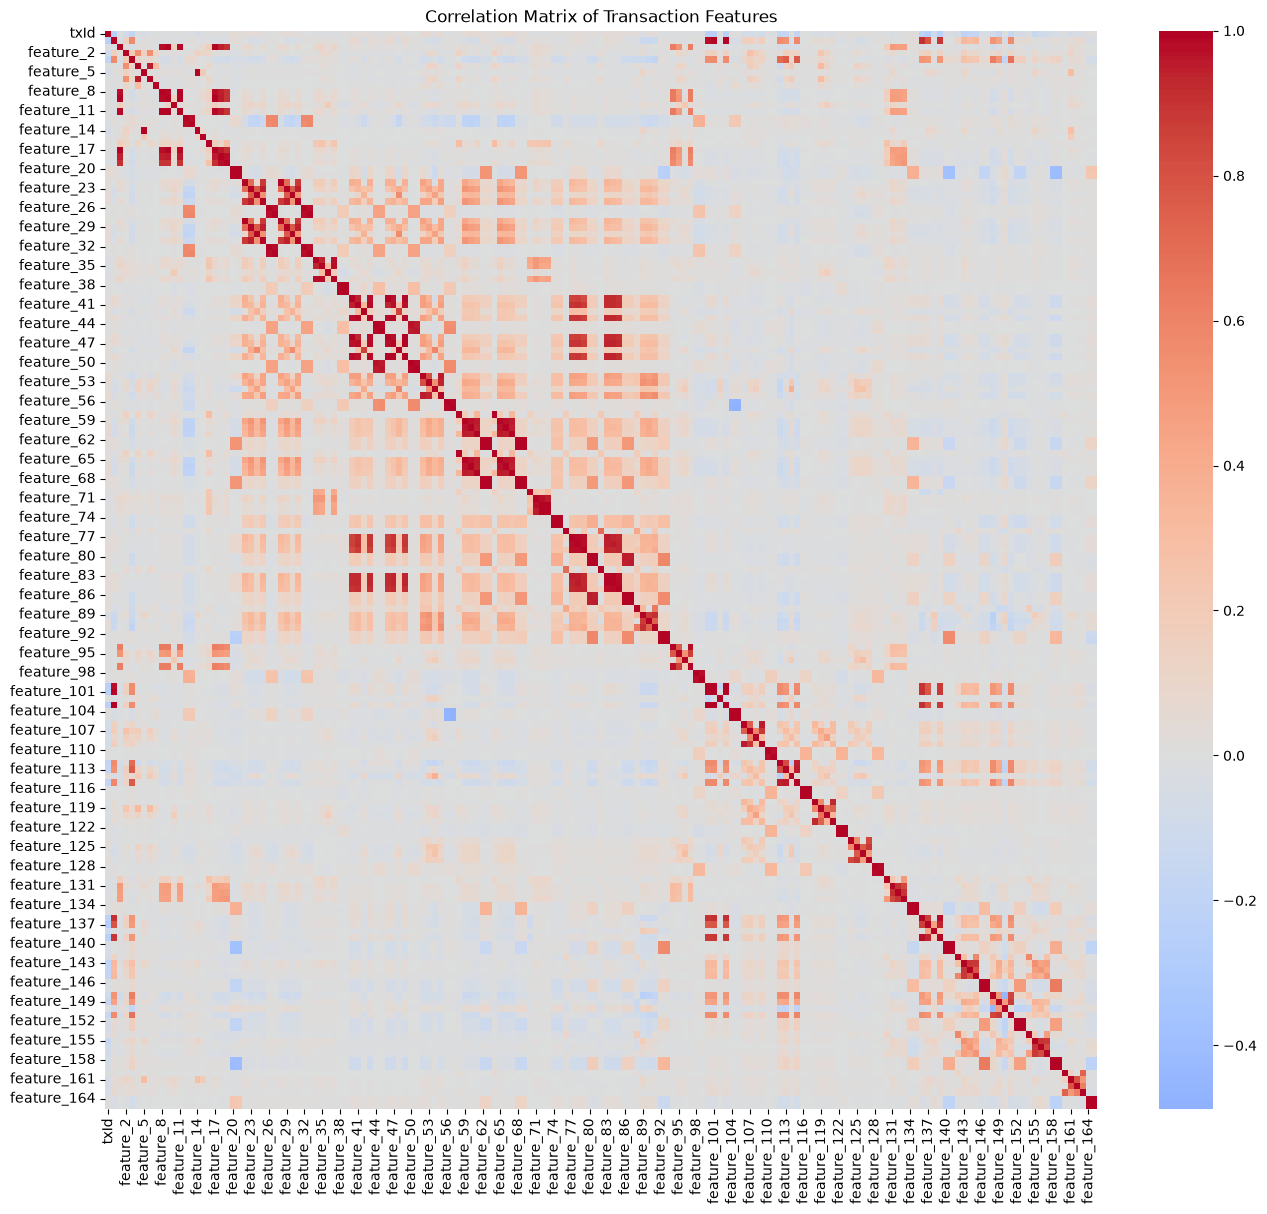

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = features.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Transaction Features")
plt.show()

In [ ]:
corr_matrix = features.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

high_corr.head(20)

feature_24   feature_30     1.000000
feature_23   feature_29     1.000000
feature_25   feature_31     1.000000
feature_22   feature_28     1.000000
feature_59   feature_65     1.000000
feature_61   feature_67     1.000000
feature_60   feature_66     1.000000
feature_58   feature_64     0.999997
feature_26   feature_32     0.999589
feature_27   feature_33     0.999573
feature_152  feature_153    0.999418
feature_8    feature_11     0.998702
feature_101  feature_103    0.998631
feature_158  feature_159    0.997194
feature_92   feature_93     0.997029
feature_146  feature_147    0.996897
feature_116  feature_117    0.996811
feature_74   feature_75     0.996794
feature_80   feature_81     0.996519
feature_86   feature_87     0.996482
dtype: float64

### Observation

The correlation analysis reveals that most transaction features exhibit relatively weak pairwise correlations, indicating that the anonymized feature space captures diverse aspects of Bitcoin transaction behaviour rather than redundant information.

Several localized groups of features demonstrate extremely strong positive correlations, with multiple feature pairs exhibiting correlation coefficients approaching or equal to **1.0**. These highly correlated groups are likely a consequence of the engineered and anonymized nature of the Elliptic feature space, where related statistical descriptors may have been derived from similar transaction characteristics.

Importantly, these strong correlations are confined to specific feature groups rather than being widespread across the entire feature space. Consequently, severe global multicollinearity is not observed.

Although a small number of feature pairs are nearly identical from a linear correlation perspective, no feature elimination is performed at this stage. Since Graph Neural Networks and tree-based learning algorithms are generally robust to correlated inputs, all transaction features are retained during baseline model development. Any future feature selection decisions will be guided by empirical model performance and explainability analyses rather than correlation alone.

# 4.5 Feature Space Summary

The feature space exploration provides several important insights into the characteristics of the anonymized transaction features contained within the Elliptic Bitcoin Dataset.

The principal findings from this chapter are summarized below:

- The transaction features have been standardized by the dataset creators, resulting in a consistent numerical scale across all variables.
- Despite standardization, the underlying feature distributions remain highly heterogeneous, with representative features exhibiting distinct statistical behaviours.
- Numerous features display substantial positive skewness, indicating that uncommon transaction patterns occupy the tails of their respective distributions.
- Correlation analysis reveals that most transaction features are only weakly correlated, while a limited number of localized feature groups exhibit very strong positive correlations. These correlations are expected due to the engineered nature of the anonymized feature space rather than widespread redundancy.
- No feature elimination is performed during exploratory analysis. Since Graph Neural Networks are generally robust to correlated inputs, the complete feature space is preserved for baseline model development.

Overall, the feature exploration demonstrates that the transaction attributes contain diverse statistical information that is suitable for graph-based learning. These observations provide the foundation for the subsequent analysis of class imbalance, temporal behaviour, and graph topology before Graph Neural Network training.

# Chapter 5: Class & Temporal Analysis

## 5.1 Overall Class Distribution

### Research Question

**How are transactions distributed across the available class labels, and what challenges does this introduce for illicit transaction detection?**

### Objective

The Elliptic Bitcoin Dataset categorizes transactions into three classes: **licit**, **illicit**, and **unknown**. Understanding the distribution of these classes is essential because severe class imbalance directly influences model selection, evaluation metrics, and training strategy.

This analysis quantifies the class distribution across the entire dataset and establishes the motivation for using imbalance-aware evaluation metrics and learning algorithms.

In [ ]:
class_counts = (
    classes["class"]
    .value_counts()
    .sort_index()
)

print(class_counts)

class_percent = (
    classes["class"]
    .value_counts(normalize=True)
    .sort_index()*100
)

print(class_percent)

class
1            4545
2           42019
unknown    157205
Name: count, dtype: int64
class
1           2.230467
2          20.620899
unknown    77.148634
Name: proportion, dtype: float64


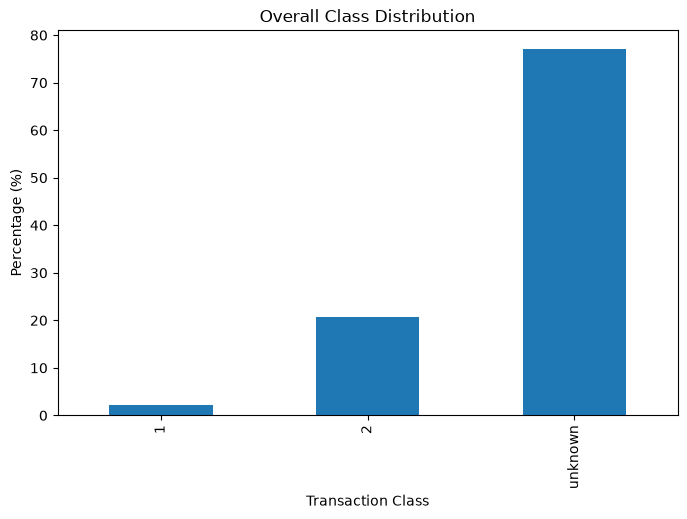

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

class_percent.plot(
    kind="bar"
)

plt.ylabel("Percentage (%)")
plt.xlabel("Transaction Class")
plt.title("Overall Class Distribution")

plt.show()

### Observation

The Elliptic Bitcoin Dataset exhibits a highly imbalanced class distribution. Of the **203,769** transactions, **157,205 (77.15%)** belong to the **unknown** class, **42,019 (20.62%)** are labelled as **licit**, and only **4,545 (2.23%)** are labelled as **illicit**.

The overwhelming proportion of unknown transactions reflects the real-world challenge of cryptocurrency fraud detection, where only a small subset of transactions can be confidently labelled. More importantly, the illicit class represents only a very small fraction of the entire dataset, making it the minority class of primary interest.

This severe imbalance has important implications for model development. Conventional accuracy is likely to produce misleadingly high performance by favouring the majority classes. Consequently, the Graph Neural Network will be evaluated using imbalance-aware metrics such as **Precision, Recall, F1-score, ROC-AUC, and Precision-Recall AUC**. Furthermore, appropriate strategies such as class-weighted loss functions will be considered during model training to reduce bias towards the majority classes.

> **Key Takeaway**
>
> Only **2.23%** of all transactions are labelled as illicit. This confirms that illicit transaction detection is an extreme class imbalance problem rather than a conventional multi-class classification task. Every subsequent modeling decision—including evaluation metrics, loss function, and sampling strategy—must account for this imbalance.

## 5.2 Class Distribution Across Time Steps

### Research Question

**How does the distribution of licit, illicit, and unknown transactions evolve across the 49 temporal snapshots of the Bitcoin transaction network?**

### Objective

Unlike conventional tabular datasets, the Elliptic Bitcoin Dataset is temporally ordered into 49 sequential time steps. Understanding how class proportions evolve over time is essential for determining whether a random train-test split would violate the chronological structure of the data.

This analysis examines the class composition at each time step to identify temporal variations in illicit activity and to provide evidence for adopting a chronological training, validation, and testing strategy.

In [ ]:
class_time = (
    merged.groupby(["time_step", "class"])
          .size()
          .unstack(fill_value=0)
)

class_time

class,1,2,unknown
time_step,,,
1,17,2130,5733
2,18,1099,3427
3,11,1268,5342
4,30,1410,4253
5,8,1874,4921
6,5,480,3843
7,102,1101,4845
8,67,1098,3292
9,248,530,4218


<Figure size 1400x600 with 0 Axes>

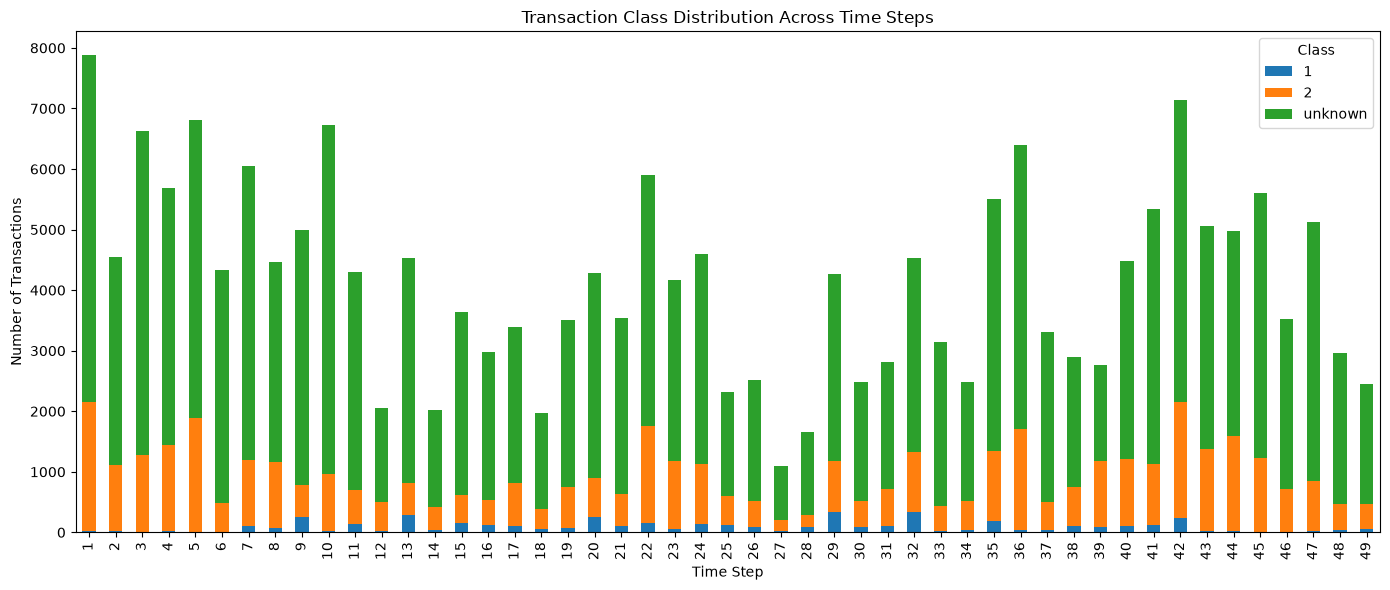

In [ ]:
plt.figure(figsize=(14,6))

class_time.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6)
)

plt.title("Transaction Class Distribution Across Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")

plt.legend(title="Class")

plt.tight_layout()

plt.show()

In [ ]:
class_time_percent = (
    class_time.div(
        class_time.sum(axis=1),
        axis=0
    ) * 100
)

<Figure size 1500x600 with 0 Axes>

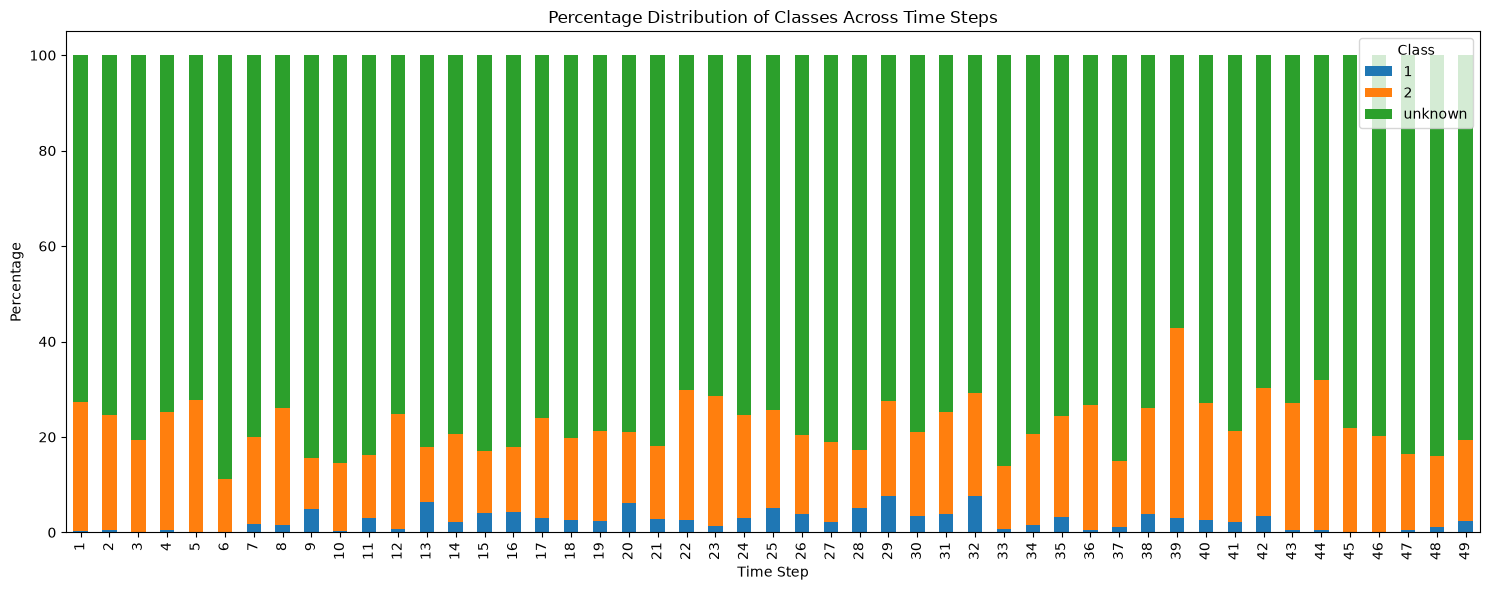

In [ ]:
plt.figure(figsize=(15,6))

class_time_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(15,6)
)

plt.ylabel("Percentage")

plt.xlabel("Time Step")

plt.title("Percentage Distribution of Classes Across Time Steps")

plt.legend(title="Class")

plt.tight_layout()

plt.show()

In [ ]:
class_time.head()

class,1,2,unknown
time_step,,,
1,17,2130,5733
2,18,1099,3427
3,11,1268,5342
4,30,1410,4253
5,8,1874,4921


### Observation

The temporal analysis reveals that the class composition of the Bitcoin transaction network is not constant throughout the 49 observation periods. Although the **unknown** class consistently dominates each time step, the proportions of **licit** and **illicit** transactions fluctuate over time rather than remaining fixed.

The analysis also shows noticeable variation in the total number of transactions observed during each time step, indicating that network activity changes throughout the observation period. Consequently, both the transaction volume and class distribution exhibit temporal dynamics.

These findings suggest that the dataset is **non-stationary**, meaning that the statistical characteristics of the transaction network evolve over time. Under such conditions, randomly splitting the dataset into training and testing sets would mix information from different stages of the network's evolution, potentially introducing temporal leakage.

Therefore, a chronological train-validation-test split is adopted in the subsequent modeling stage to better simulate a real-world fraud detection scenario in which future transactions are predicted using only historical information.

## 5.3 Transaction Activity Across Time Steps

### Research Question

**How does the volume of Bitcoin transactions evolve throughout the observation period?**

### Objective

Beyond understanding the class composition of the dataset, it is equally important to examine how overall transaction activity changes over time. Variations in transaction volume may indicate changes in network activity and can influence the amount of information available for graph construction and model training.

This analysis quantifies the total number of transactions observed at each of the 49 time steps to better understand the temporal dynamics of the Bitcoin transaction network.

In [ ]:
transactions_per_step = (
    merged.groupby("time_step")
          .size()
)

transactions_per_step.head()

time_step
1    7880
2    4544
3    6621
4    5693
5    6803
dtype: int64

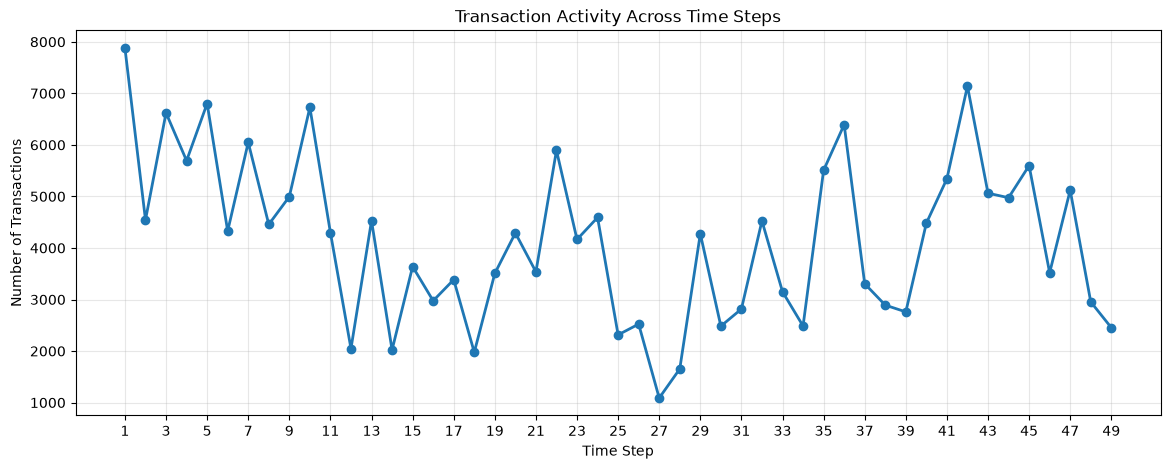

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    transactions_per_step.index,
    transactions_per_step.values,
    marker="o",
    linewidth=2,
)

plt.title("Transaction Activity Across Time Steps")

plt.xlabel("Time Step")

plt.ylabel("Number of Transactions")

plt.grid(alpha=0.3)

plt.xticks(range(1, 50, 2))

plt.show()

In [ ]:
transactions_per_step.describe()

count      49.000000
mean     4158.551020
std      1592.470592
min      1089.000000
25%      2891.000000
50%      4291.000000
75%      5121.000000
max      7880.000000
dtype: float64

### Observation

The temporal activity analysis shows that the number of Bitcoin transactions varies considerably across the 49 observation periods rather than remaining constant. Transaction activity is highest during the early stages of the dataset, decreases substantially around the middle time steps, and increases again during several later periods before declining toward the end.

These fluctuations indicate that the Bitcoin transaction network is dynamic, with periods of both high and low activity. Consequently, each temporal snapshot represents a different level of network participation, resulting in graphs of varying size and density.

This finding further supports treating the dataset as a temporal graph rather than a collection of independent observations. Since network activity evolves over time, preserving the chronological ordering during model development provides a more realistic representation of operational cryptocurrency fraud detection.

### Statistical Summary

The descriptive statistics confirm substantial variation in transaction volume across the observation period. The large difference between the minimum and maximum number of transactions per time step demonstrates that the transaction network experiences considerable fluctuations in activity, reinforcing the importance of temporal analysis before graph construction.

## 5.4 Temporal Train–Validation–Test Split Justification

### Research Question

**How should the Elliptic Bitcoin Dataset be partitioned to accurately evaluate a graph-based fraud detection model while avoiding information leakage?**

### Objective

The previous analyses demonstrated that both transaction activity and class composition evolve across the 49 temporal snapshots of the Bitcoin transaction network. These findings indicate that the dataset is not independently and identically distributed (IID), but instead follows a chronological sequence in which later transactions represent future observations.

Using a random train-test split would mix transactions from different time periods, allowing the model to indirectly learn patterns from future network states. Such information leakage would lead to overly optimistic evaluation metrics and would not reflect a realistic fraud detection environment.

Therefore, this project adopts a chronological train-validation-test split in which the model is trained exclusively on historical transactions and evaluated on future transactions that were never observed during training. This methodology closely resembles real-world cryptocurrency monitoring systems, where predictions are always made on newly arriving transactions.

In [ ]:
train = merged[merged["time_step"] <= 34]

val = merged[
    (merged["time_step"] >= 35) &
    (merged["time_step"] <= 41)
]

test = merged[
    merged["time_step"] >= 42
]

In [ ]:
split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Time Steps": ["1–34", "35–41", "42–49"],
    "Transactions": [
        len(train),
        len(val),
        len(test)
    ]
})

split_summary["Percentage"] = (
    split_summary["Transactions"] /
    len(merged) * 100
).round(2)

split_summary

,Dataset,Time Steps,Transactions,Percentage
0,Train,1–34,136265,66.87
1,Validation,35–41,30680,15.06
2,Test,42–49,36824,18.07


### Observation

The dataset is partitioned chronologically into three non-overlapping subsets consisting of **136,265 training transactions (66.87%)**, **30,680 validation transactions (15.06%)**, and **36,824 testing transactions (18.07%)**.

Rather than randomly distributing transactions across the three subsets, the temporal ordering of the Bitcoin transaction network is preserved. The training set contains only historical observations (Time Steps 1–34), the validation set contains intermediate observations (Time Steps 35–41), and the test set contains the most recent transactions (Time Steps 42–49).

This chronological partition prevents information leakage from future network states into the training process and provides a realistic assessment of the model's ability to generalize to unseen Bitcoin transactions. Consequently, the reported evaluation metrics more closely represent the performance expected in a real-world cryptocurrency fraud detection system.

## 5.5 Chapter Summary

The class and temporal analyses reveal several important characteristics of the Elliptic Bitcoin Dataset that directly influence the design of the Graph Neural Network.

The principal findings from this chapter are summarized below:

- The dataset exhibits severe class imbalance, with illicit transactions accounting for only **2.23%** of all observations.
- The unknown class dominates every temporal snapshot, reflecting the limited availability of labelled cryptocurrency transactions.
- The distribution of licit and illicit transactions varies across the 49 time steps, demonstrating that the dataset evolves over time rather than remaining statistically stationary.
- Overall transaction activity fluctuates considerably throughout the observation period, indicating dynamic changes in the Bitcoin transaction network.
- To prevent temporal information leakage, a chronological train-validation-test split is adopted instead of a random partition.

Collectively, these findings establish the experimental methodology that will be used throughout the Graph Neural Network development process. The next chapter focuses on constructing a directed Bitcoin transaction graph from the tabular transaction records, thereby transforming the dataset into a representation suitable for graph-based deep learning.

# Chapter 6: Graph Construction

## 6.1 Why Graph Representation?

### Research Question

**Why is a graph representation more appropriate than a conventional tabular representation for illicit Bitcoin transaction detection?**

### Objective

Traditional machine learning algorithms assume that observations are independent of one another. However, Bitcoin transactions naturally form a network in which every transaction is connected to previous and subsequent transactions through the flow of cryptocurrency.

Representing the dataset as a graph preserves these relationships by modeling transactions as interconnected entities rather than isolated records. This enables Graph Neural Networks to learn not only from the attributes of individual transactions but also from the structural information contained within the surrounding transaction network.

Consequently, transforming the Elliptic Bitcoin Dataset into a directed graph provides a more realistic representation of cryptocurrency transaction behaviour and forms the foundation for graph-based fraud detection.

## 6.2 Node Definition

### Objective

Each Bitcoin transaction is represented as a node within the transaction graph.

Every node contains:

- A unique transaction identifier.
- A temporal identifier representing the observation period.
- 166 anonymized transaction features.
- A transaction label indicating whether the transaction is licit, illicit, or unknown.

Thus, every node represents a complete transaction together with its associated attributes while preserving its position within the transaction network.

In [ ]:
import networkx as nx

In [ ]:

G = nx.DiGraph()

for _, row in merged.iterrows():

    G.add_node(
        row["txId"],
        time_step=row["time_step"],
        label=row["class"]
    )

## 6.3 Edge Definition

### Objective

Directed edges represent the flow of Bitcoin between transactions.

An edge is created whenever one transaction directly references another transaction within the blockchain transaction history.

Because Bitcoin transactions possess an inherent direction of value transfer, the resulting graph is modeled as a directed graph (DiGraph). This preserves the chronological movement of cryptocurrency and enables Graph Neural Networks to exploit directional neighbourhood information during message passing.

In [ ]:
for _, row in edges.iterrows():

    G.add_edge(
        row["txId1"],
        row["txId2"]
    )

In [ ]:
graph_summary = pd.DataFrame({
    "Property": [
        "Number of Nodes",
        "Number of Edges",
        "Graph Type",
        "Directed"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        type(G).__name__,
        G.is_directed()
    ]
})

graph_summary

,Property,Value
0,Number of Nodes,203769
1,Number of Edges,234355
2,Graph Type,DiGraph
3,Directed,True


## 6.4 Graph Validation

### Research Question

**Was the Bitcoin transaction graph constructed correctly and does it preserve the expected structural properties of the original dataset?**

### Objective

Following graph construction, a series of validation checks are performed to verify the integrity of the resulting transaction network. These checks confirm that all transactions and transaction relationships have been successfully represented, that graph directionality has been preserved, and that no unexpected structural inconsistencies were introduced during graph creation.

The validation process provides confidence that the graph is suitable for subsequent structural analysis and Graph Neural Network modeling.

In [ ]:
weak_components = nx.number_weakly_connected_components(G)
strong_components = nx.number_strongly_connected_components(G)
density = nx.density(G)
isolated_nodes = list(nx.isolates(G))
num_self_loops = nx.number_of_selfloops(G)



In [ ]:
graph_summary = pd.DataFrame({
    "Property": [
        "Number of Nodes",
        "Number of Edges",
        "Graph Type",
        "Directed Graph"
    ],
    "Value": [
        f"{G.number_of_nodes():,}",
        f"{G.number_of_edges():,}",
        type(G).__name__,
        "Yes" if G.is_directed() else "No"
    ]
})

graph_summary

,Property,Value
0,Number of Nodes,"203,769"
1,Number of Edges,"234,355"
2,Graph Type,DiGraph
3,Directed Graph,Yes


In [ ]:
validation_summary = pd.DataFrame({
    "Validation Check": [
        "Number of Nodes",
        "Number of Edges",
        "Directed Graph",
        "Self-Loops",
        "Isolated Nodes",
        "Graph Density",
        "Weakly Connected Components",
        "Strongly Connected Components"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        G.is_directed(),
        nx.number_of_selfloops(G),
        len(list(nx.isolates(G))),
        round(nx.density(G), 8),
        nx.number_weakly_connected_components(G),
        nx.number_strongly_connected_components(G)
    ]
})

validation_summary

,Validation Check,Value
0,Number of Nodes,203769
1,Number of Edges,234355
2,Directed Graph,True
3,Self-Loops,0
4,Isolated Nodes,0
5,Graph Density,0.000006
6,Weakly Connected Components,49
7,Strongly Connected Components,203769


## 6.5 Graph Construction Workflow

The construction of the Bitcoin transaction graph follows the workflow illustrated below:

```

```text
Raw Dataset
    │
    ▼
Load Transaction Features
    │
    ▼
Load Transaction Classes
    │
    ▼
Load Transaction Edges
    │
    ▼
Merge Datasets
    │
    ▼
Create Transaction Nodes
    │
    ▼
Create Directed Edges
    │
    ▼
Construct NetworkX DiGraph
    │
    ▼
Validate Graph Integrity
    │
    ▼
Graph Ready for Structural Analysis
```


## 6.6 Chapter Summary

This chapter transformed the Elliptic Bitcoin Dataset from a collection of tabular records into a directed transaction graph suitable for graph-based machine learning.

The principal outcomes of this chapter are summarized below:

- Every Bitcoin transaction was successfully represented as a graph node.
- Transaction relationships were preserved through directed edges representing the flow of cryptocurrency.
- The graph construction process maintained the temporal and relational structure of the original blockchain transaction network.
- Validation confirmed the correctness of the graph by verifying node count, edge count, graph directionality, and structural integrity.
- The resulting graph forms the foundation for subsequent structural analysis and Graph Neural Network development.

Having successfully constructed and validated the transaction graph, the next chapter investigates its structural properties to better understand the topology of the Bitcoin transaction network before GraphSAGE model development.

# Chapter 7: Graph Structural Analysis

## 7.1 Graph Statistics

### Research Question

**What are the fundamental structural characteristics of the constructed Bitcoin transaction graph?**

### Objective

Before investigating advanced graph properties, it is essential to understand the overall size and connectivity of the Bitcoin transaction network. Basic graph statistics provide an overview of the network's scale and establish the foundation for subsequent structural analyses.

## 7.2 Degree Distribution

### Research Question

**How are transaction connections distributed throughout the Bitcoin transaction network, and what structural insights can be obtained from the degree distribution?**

### Objective

The degree of a node is defined as the total number of edges connected to it, representing the sum of its incoming and outgoing transaction relationships.

Degree distribution is one of the most fundamental properties of a graph because it reveals how connectivity is distributed across the network. It helps identify highly connected transactions (hub nodes), evaluate the sparsity of the graph, and understand how information is likely to propagate during Graph Neural Network message passing.

Since GraphSAGE aggregates information from neighbouring nodes, understanding the degree distribution is essential for interpreting how different regions of the transaction network contribute to node representations.

In [ ]:
degree_df = pd.DataFrame(
    G.degree(),
    columns=["Transaction", "Degree"]
)

degree_df.head()

,Transaction,Degree
0,230425980,2
1,5530458,2
2,232022460,3
3,232438397,161
4,230460314,10


In [ ]:
degree_df["Degree"].describe()

count    203769.000000
mean          2.300203
std           4.328377
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max         473.000000
Name: Degree, dtype: float64

In [ ]:
degree_df["Degree"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

0.25     1.0
0.50     2.0
0.75     2.0
0.90     3.0
0.95     4.0
0.99    13.0
Name: Degree, dtype: float64

In [ ]:
degree_df.sort_values(
    "Degree",
    ascending=False
).head(10)

,Transaction,Degree
94301,2984918,473
130,89273,289
51371,43388675,284
51437,68705820,247
148292,30699343,241
35892,96576418,239
24761,225859042,212
19138,279187194,211
58098,234890810,199
189738,196107869,188


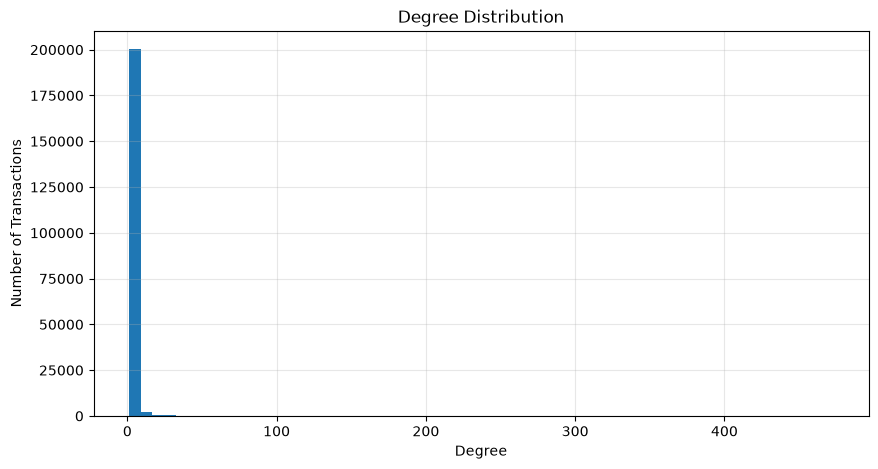

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    degree_df["Degree"],
    bins=60
)

plt.title("Degree Distribution")

plt.xlabel("Degree")

plt.ylabel("Number of Transactions")

plt.grid(alpha=0.3)

plt.show()

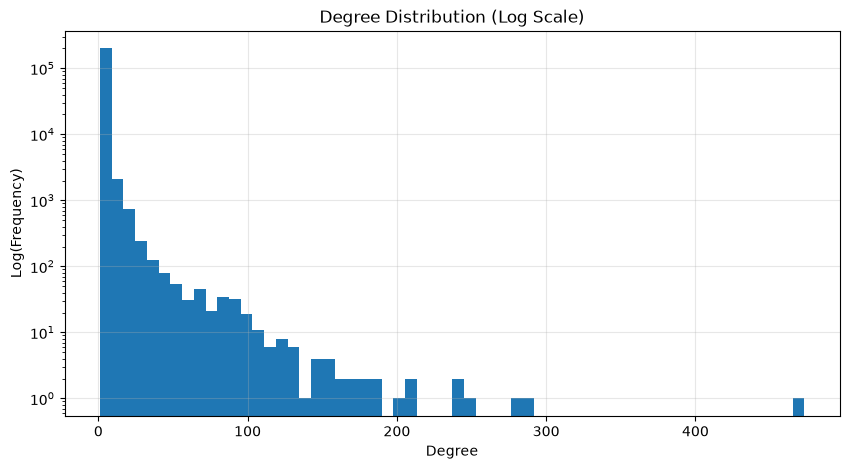

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    degree_df["Degree"],
    bins=60,
    log=True
)

plt.title("Degree Distribution (Log Scale)")

plt.xlabel("Degree")

plt.ylabel("Log(Frequency)")

plt.grid(alpha=0.3)

plt.show()

C:\Users\chirag\AppData\Local\Temp\ipykernel_41004\1680993109.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


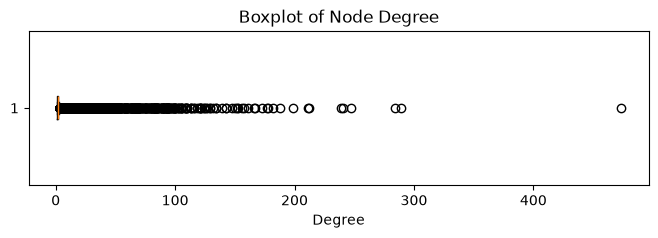

In [ ]:
plt.figure(figsize=(8,2))

plt.boxplot(
    degree_df["Degree"],
    vert=False
)

plt.title("Boxplot of Node Degree")

plt.xlabel("Degree")

plt.show()

In [ ]:
hub_threshold = degree_df["Degree"].quantile(0.99)

hub_nodes = degree_df[
    degree_df["Degree"] > hub_threshold
]

print(f"99th Percentile Threshold : {hub_threshold}")
print(f"Number of Hub Nodes       : {len(hub_nodes):,}")

99th Percentile Threshold : 13.0
Number of Hub Nodes       : 1,987


### Observation

The Bitcoin transaction network exhibits a highly skewed degree distribution, with the majority of transactions connected to only a small number of neighbouring nodes. Although the average node degree is **2.30**, the median degree is **2**, indicating that a typical transaction interacts with very few other transactions.

The percentile analysis further demonstrates the sparse nature of the network. Approximately **99%** of all transactions have a degree of **13 or less**, whereas the highest-degree transaction is connected to **473** neighbouring transactions.

The histogram and log-scale visualization reveal a long-tailed degree distribution, where a small number of highly connected hub transactions coexist with a very large population of low-degree transactions. This behaviour is characteristic of many real-world financial and blockchain networks.

The hub analysis confirms that only a very small fraction of transactions possess exceptionally high connectivity, suggesting that these nodes may correspond to important aggregation points such as exchanges or other high-activity entities.

From a Graph Neural Network perspective, these findings are particularly important. GraphSAGE constructs node embeddings by aggregating information from neighbouring transactions. Consequently, highly connected hub nodes have the potential to influence a large number of surrounding node representations, whereas the majority of low-degree nodes rely on information from relatively small local neighbourhoods.

## 7.3 In-Degree Distribution

### Research Question

**How are incoming transaction references distributed across the Bitcoin transaction network?**

### Objective

The in-degree of a node represents the number of incoming edges directed towards a transaction. In the context of the Bitcoin transaction graph, a higher in-degree indicates that a transaction receives inputs from a larger number of preceding transactions.

Analysing the in-degree distribution helps identify transactions that aggregate funds from multiple sources and provides additional insight into the structural characteristics of the network beyond the overall degree distribution.

In [ ]:
in_degree_df = pd.DataFrame(
    G.in_degree(),
    columns=["Transaction", "In_Degree"]
)

in_degree_df.head()

,Transaction,In_Degree
0,230425980,1
1,5530458,1
2,232022460,1
3,232438397,160
4,230460314,2


In [ ]:
in_degree_df["In_Degree"].describe()

count    203769.000000
mean          1.150101
std           3.911132
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max         284.000000
Name: In_Degree, dtype: float64

In [ ]:
in_degree_df["In_Degree"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

0.25    0.0
0.50    1.0
0.75    1.0
0.90    1.0
0.95    2.0
0.99    9.0
Name: In_Degree, dtype: float64

In [ ]:
in_degree_df.sort_values(
    "In_Degree",
    ascending=False
).head(10)

,Transaction,In_Degree
51371,43388675,284
51437,68705820,247
148292,30699343,241
35892,96576418,239
24761,225859042,212
19138,279187194,211
58098,234890810,199
189738,196107869,188
51567,43397277,182
51392,68706499,178


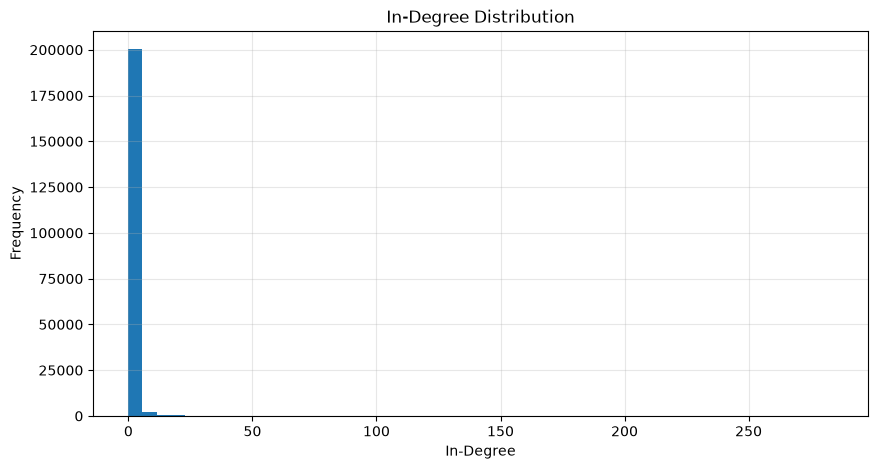

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    in_degree_df["In_Degree"],
    bins=50
)

plt.title("In-Degree Distribution")

plt.xlabel("In-Degree")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

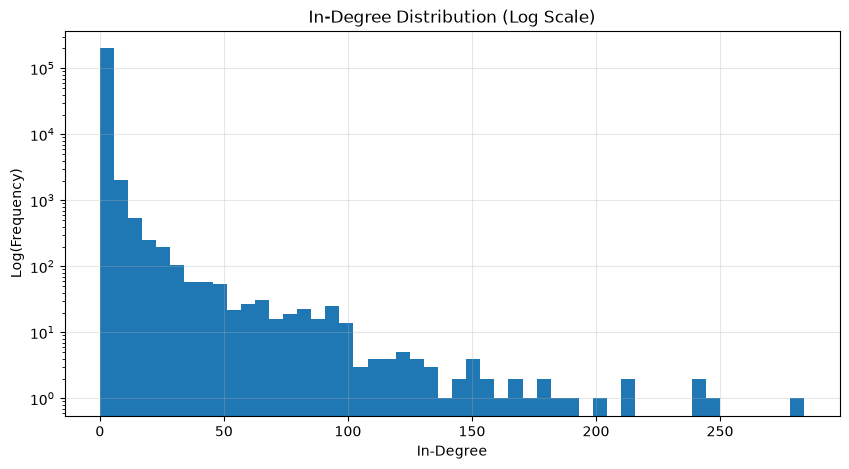

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    in_degree_df["In_Degree"],
    bins=50,
    log=True
)

plt.title("In-Degree Distribution (Log Scale)")

plt.xlabel("In-Degree")

plt.ylabel("Log(Frequency)")

plt.grid(alpha=0.3)

plt.show()

### Observation

The in-degree distribution is highly skewed, with the majority of Bitcoin transactions receiving very few incoming connections.

The average in-degree is **1.15**, while the median in-degree is **1**, indicating that a typical transaction receives input from only a single neighbouring transaction. Furthermore, **99%** of all transactions have an in-degree of **9 or less**, demonstrating that highly aggregated transactions are relatively rare.

The histogram and log-scale visualization reveal a pronounced long-tail distribution. Although most transactions receive inputs from one or two previous transactions, a very small number of transactions accumulate inputs from hundreds of other transactions. The largest observed in-degree in the network is **284**.

These high in-degree transactions are likely to represent aggregation points where funds originating from multiple independent transactions are combined into a single transaction. Such behaviour is commonly associated with high-volume entities, including cryptocurrency exchanges, custodial wallets, or large-scale transaction batching mechanisms.

Compared to the overall degree distribution analysed previously, the in-degree values are generally lower, suggesting that extremely high connectivity within the network is not solely driven by incoming transaction references but also by outgoing transaction relationships. This distinction motivates a separate analysis of the out-degree distribution in the following section.

## 7.4 Out-Degree Distribution

### Research Question

**How are outgoing transaction references distributed across the Bitcoin transaction network?**

### Objective

The out-degree of a node represents the number of outgoing edges originating from a transaction. Within the Bitcoin transaction graph, a higher out-degree indicates that a transaction distributes funds to a larger number of subsequent transactions.

Analysing the out-degree distribution provides insight into fund dispersion patterns, identifies highly distributive transactions, and complements the in-degree analysis by characterizing how cryptocurrency propagates through the transaction network.

In [ ]:
out_degree_df = pd.DataFrame(
    G.out_degree(),
    columns=["Transaction", "Out_Degree"]
)

out_degree_df.head()

,Transaction,Out_Degree
0,230425980,1
1,5530458,1
2,232022460,2
3,232438397,1
4,230460314,8


In [ ]:
out_degree_df["Out_Degree"].describe()

count    203769.000000
mean          1.150101
std           1.894740
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         472.000000
Name: Out_Degree, dtype: float64

In [ ]:
out_degree_df["Out_Degree"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

0.25    1.0
0.50    1.0
0.75    1.0
0.90    2.0
0.95    2.0
0.99    5.0
Name: Out_Degree, dtype: float64

In [ ]:
out_degree_df.sort_values(
    "Out_Degree",
    ascending=False
).head(10)

,Transaction,Out_Degree
94301,2984918,472
130,89273,288
141786,102570,122
133793,3181,112
198381,7952,99
113795,1891081,95
184339,143705,92
51407,565334,90
108968,488266,88
174167,793584,82


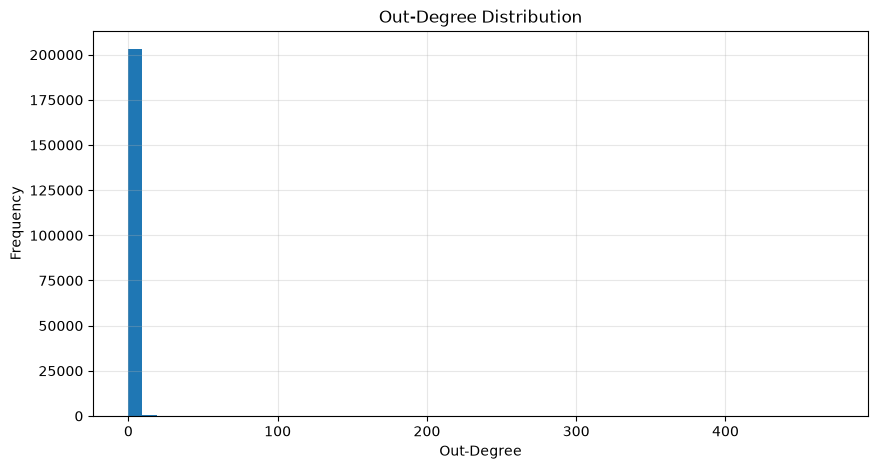

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    out_degree_df["Out_Degree"],
    bins=50
)

plt.title("Out-Degree Distribution")

plt.xlabel("Out-Degree")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

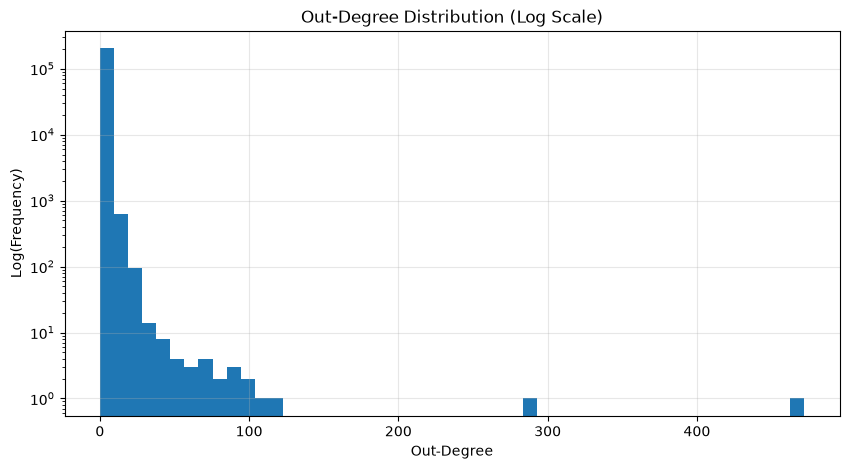

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    out_degree_df["Out_Degree"],
    bins=50,
    log=True
)

plt.title("Out-Degree Distribution (Log Scale)")

plt.xlabel("Out-Degree")

plt.ylabel("Log(Frequency)")

plt.grid(alpha=0.3)

plt.show()

### Observation

The out-degree distribution exhibits a pronounced long-tail pattern similar to the in-degree distribution. Most Bitcoin transactions produce only a small number of outgoing connections, while a very small number of transactions distribute funds to an exceptionally large number of neighbouring transactions.

The average out-degree is approximately **1.15**, reflecting the sparse nature of the transaction network. However, the maximum observed out-degree reaches **472**, substantially exceeding the maximum in-degree of **284**.

This difference suggests that, although both aggregation and distribution behaviours exist within the Bitcoin network, a small number of transactions distribute funds to many more destinations than individual transactions receive from distinct sources.

Such highly connected outgoing transactions may correspond to exchanges, payment processors, mining pools, or transaction batching mechanisms that transfer cryptocurrency to a large number of recipient addresses.

Together, the in-degree and out-degree analyses demonstrate that the Bitcoin transaction graph is structurally sparse but contains a small number of highly influential hub transactions responsible for aggregating or distributing large volumes of transactional relationships.

In [ ]:
degree_comparison = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Maximum"
    ],
    "In-Degree": [
        in_degree_df["In_Degree"].mean(),
        in_degree_df["In_Degree"].median(),
        in_degree_df["In_Degree"].max()
    ],
    "Out-Degree": [
        out_degree_df["Out_Degree"].mean(),
        out_degree_df["Out_Degree"].median(),
        out_degree_df["Out_Degree"].max()
    ]
})

degree_comparison.round(2)

,Metric,In-Degree,Out-Degree
0,Mean,1.15,1.15
1,Median,1.00,1.00
2,Maximum,284.00,472.00


### Comparison of In-Degree and Out-Degree

The comparison between the in-degree and out-degree distributions reveals that the Bitcoin transaction network is balanced on average, with both measures exhibiting an identical mean (1.15) and median (1). This is expected because every directed edge contributes exactly one incoming connection and one outgoing connection within the graph.

However, the maximum out-degree (**472**) is considerably larger than the maximum in-degree (**284**). This indicates that although transaction aggregation and fund distribution are both present within the network, a small number of transactions distribute funds to substantially more neighbouring transactions than any single transaction receives from distinct sources.

This asymmetry suggests the presence of highly distributive hub transactions, which may correspond to exchanges, payment processors, mining pools, or transaction batching mechanisms that transfer cryptocurrency to many recipients. Conversely, the largest aggregating transactions collect inputs from fewer distinct sources.

Overall, both analyses confirm that the Bitcoin transaction graph is sparse, while simultaneously containing a small number of structurally important hub nodes that dominate the network's connectivity.

## 7.5 Connected Components

### Research Question

**How connected is the Bitcoin transaction graph, and does it consist of one large network or multiple disconnected subnetworks?**

### Objective

Connected component analysis evaluates the overall connectivity of the transaction graph by identifying groups of transactions that are reachable from one another.

For directed graphs, two forms of connectivity are analysed:

- **Weakly Connected Components (WCCs):** Connectivity is assessed by ignoring edge direction.
- **Strongly Connected Components (SCCs):** Connectivity requires that every node be reachable from every other node while respecting edge direction.

These analyses provide insight into the fragmentation of the Bitcoin transaction network and its suitability for graph-based learning.

In [ ]:
largest_wcc = max(
    nx.weakly_connected_components(G),
    key=len
)

print(f"Largest Weakly Connected Component: {len(largest_wcc):,}")
print(f"Total Weakly Connected Components: {nx.number_weakly_connected_components(G):,}")

Largest Weakly Connected Component: 7,880
Total Weakly Connected Components: 49


In [ ]:
largest_scc = max(
    nx.strongly_connected_components(G),
    key=len
)

print(f"Largest Strongly Connected Component: {len(largest_scc):,}")
print(f"Total Strongly Connected Components: {nx.number_strongly_connected_components(G):,}")

Largest Strongly Connected Component: 1
Total Strongly Connected Components: 203,769


### Observation

The weakly connected component analysis reveals that the Bitcoin transaction graph consists of **49 disconnected subnetworks**, with the largest component containing **7,880 transactions**.

Interestingly, the number of weakly connected components exactly matches the **49 temporal snapshots** provided in the Elliptic Bitcoin Dataset. This indicates that each time step forms an independent transaction graph, confirming that the dataset is organised as a sequence of temporal network snapshots rather than a single continuously connected blockchain graph.

The strongly connected component analysis produces a markedly different result. Every transaction forms its own strongly connected component, resulting in **203,769 strongly connected components**, each containing a single node.

This behaviour is expected because Bitcoin transactions form a **Directed Acyclic Graph (DAG)**. Cryptocurrency flows forward from earlier transactions to later transactions without forming directed cycles. Consequently, no pair of transactions is mutually reachable while respecting edge direction, causing each node to exist as an individual strongly connected component.

These findings confirm both the temporal nature of the Elliptic dataset and the acyclic structure of Bitcoin transaction networks, reinforcing the suitability of modelling the dataset as a directed graph for Graph Neural Network learning.

## 7.6 PageRank Analysis

### Research Question

**Which transactions are the most structurally influential within the Bitcoin transaction network?**

### Objective

PageRank is a graph centrality measure that estimates the relative importance of nodes based on both the number and quality of their incoming connections. Unlike simple degree measures, PageRank assigns greater importance to transactions that receive links from other influential transactions.

Within the Bitcoin transaction graph, PageRank helps identify structurally significant transactions that occupy central positions within the transaction network. Such transactions may correspond to important aggregation points, exchanges, payment processors, or other entities that play a major role in the propagation of cryptocurrency throughout the network.

In [ ]:
import scipy as sp

In [ ]:
pagerank = nx.pagerank(
    G,
    alpha=0.85
)

In [ ]:
pagerank_df = pd.DataFrame({
    "Transaction": pagerank.keys(),
    "PageRank": pagerank.values()
})

pagerank_df.head()

,Transaction,PageRank
0,230425980,0.000005
1,5530458,0.000006
2,232022460,0.000007
3,232438397,0.000351
4,230460314,0.000002


In [ ]:
pagerank_df["PageRank"].describe()

count    203769.000000
mean          0.000005
std           0.000010
min           0.000002
25%           0.000002
50%           0.000003
75%           0.000006
max           0.000527
Name: PageRank, dtype: float64

In [ ]:
pagerank_df.sort_values(
    "PageRank",
    ascending=False
).head(10)

,Transaction,PageRank
116675,163832295,0.000527
24761,225859042,0.000521
64727,339157927,0.000485
46397,179084283,0.000474
51371,43388675,0.000470
157798,99409352,0.000461
129401,355176026,0.000431
167220,73405590,0.000410
126379,355110272,0.000406
174185,91882349,0.000405


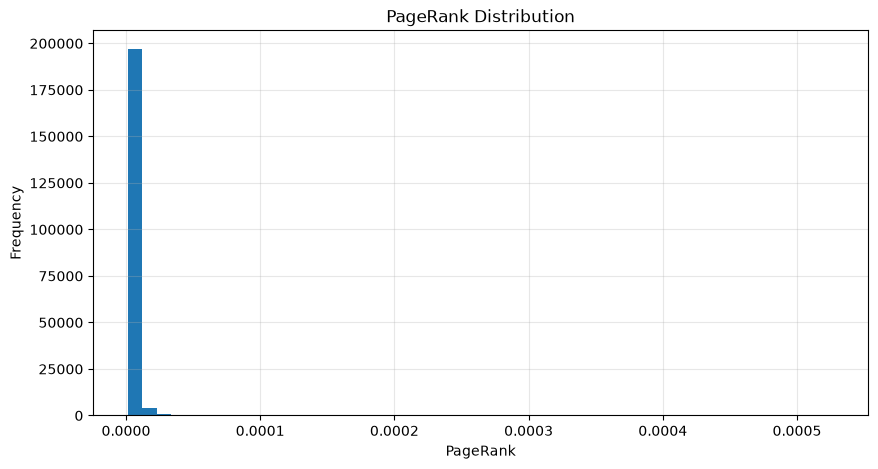

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    pagerank_df["PageRank"],
    bins=50
)

plt.title("PageRank Distribution")

plt.xlabel("PageRank")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
top_pagerank = pagerank_df.sort_values(
    "PageRank",
    ascending=False
).head(20)

top_pagerank

,Transaction,PageRank
116675,163832295,0.000527
24761,225859042,0.000521
64727,339157927,0.000485
46397,179084283,0.000474
51371,43388675,0.000470
157798,99409352,0.000461
129401,355176026,0.000431
167220,73405590,0.000410
126379,355110272,0.000406
174185,91882349,0.000405


### Observation

The PageRank distribution is highly skewed, with the vast majority of transactions receiving very small PageRank scores. The average PageRank is approximately **5 × 10⁻⁶**, while the maximum PageRank reaches **5.27 × 10⁻⁴**, indicating that only a very small number of transactions possess exceptionally high structural importance.

The histogram demonstrates that most transactions occupy peripheral positions within the transaction graph, whereas a limited number of nodes receive substantially higher PageRank values. These influential transactions are not necessarily those with the largest number of neighbours; rather, they receive connections from other structurally important transactions.

Several transactions identified among the highest PageRank scores also appeared in the high in-degree and degree analyses, suggesting that these transactions function as important aggregation points within the Bitcoin transaction network. Their central location allows them to influence information propagation across large portions of the graph.

From a Graph Neural Network perspective, these structurally influential transactions play a critical role during neighbourhood aggregation. Since GraphSAGE constructs node embeddings by repeatedly exchanging information between neighbouring nodes, high PageRank transactions are likely to contribute disproportionately to the learned representations of surrounding transactions.

## 7.7 Community Detection

### Research Question

**Does the Bitcoin transaction network naturally organize into communities of closely connected transactions?**

### Objective

Community detection identifies groups of transactions that are more densely connected to one another than to the rest of the network. Such communities may represent transaction clusters, exchanges, payment processors, mining pools, or other groups of related activity.

Since the complete Bitcoin transaction graph contains over 200,000 nodes, community detection is performed on the **largest weakly connected component** to ensure computational feasibility while preserving the largest connected transaction subnetwork.

In [ ]:
largest_wcc = max(
    nx.weakly_connected_components(G),
    key=len
)

subgraph = G.subgraph(largest_wcc).copy()

print(subgraph)

DiGraph with 7880 nodes and 9164 edges


In [ ]:
undirected_subgraph = subgraph.to_undirected()

In [ ]:
from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(
    undirected_subgraph
)

In [ ]:
print(f"Number of Communities: {len(communities)}")

Number of Communities: 88


In [ ]:
community_sizes = sorted(
    [len(c) for c in communities],
    reverse=True
)

community_sizes[:10]

[638, 401, 397, 391, 365, 358, 329, 266, 219, 209]

In [ ]:
community_df = pd.DataFrame({
    "Community": range(1, len(community_sizes)+1),
    "Size": community_sizes
})

community_df.head(10)

,Community,Size
0,1,638
1,2,401
2,3,397
3,4,391
4,5,365
5,6,358
6,7,329
7,8,266
8,9,219
9,10,209


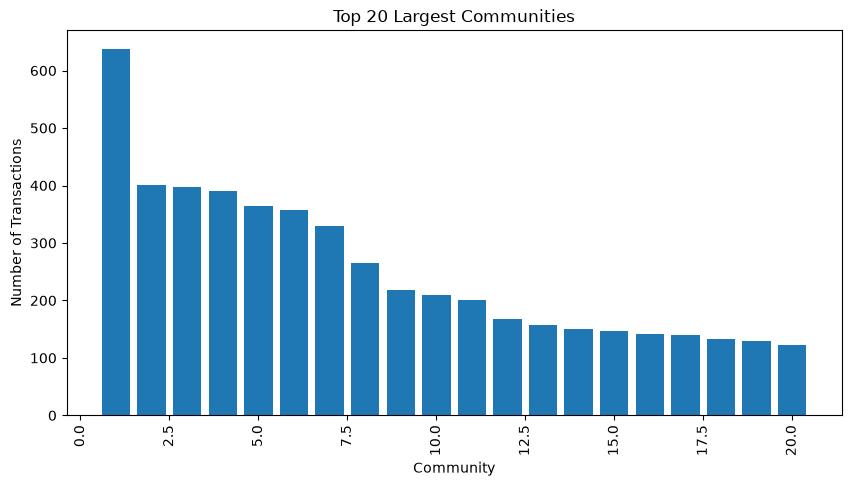

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    community_df["Community"][:20],
    community_df["Size"][:20]
)

plt.title("Top 20 Largest Communities")

plt.xlabel("Community")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=90)

plt.show()

In [ ]:
community_summary = pd.DataFrame({
    "Metric": [
        "Largest WCC Size",
        "Number of Communities",
        "Largest Community",
        "Average Community Size"
    ],
    "Value": [
        len(subgraph),
        len(communities),
        max(community_sizes),
        round(sum(community_sizes) / len(community_sizes), 2)
    ]
})

community_summary

,Metric,Value
0,Largest WCC Size,7880.00
1,Number of Communities,88.00
2,Largest Community,638.00
3,Average Community Size,89.55


### Observation

Community detection was performed on the largest weakly connected component of the Bitcoin transaction graph, containing **7,880 transactions**, using the Greedy Modularity Optimization algorithm.

The algorithm identified **88 distinct communities**, indicating that the transaction network naturally decomposes into multiple densely connected groups rather than forming one homogeneous structure.

The distribution of community sizes is heterogeneous. While one dominant community contains approximately **640 transactions**, many additional communities range between **100 and 400 transactions**. This suggests that transactional activity within the Bitcoin network is organized into multiple localized clusters of interactions.

These communities may correspond to groups of transactions generated by common entities such as cryptocurrency exchanges, payment processors, mining pools, or other related transaction workflows. Although community membership is not directly used as a model feature in this project, the presence of well-defined communities demonstrates that the graph possesses meaningful structural organization that can potentially be exploited by Graph Neural Networks during neighbourhood aggregation.

Overall, the community analysis confirms that the Bitcoin transaction network exhibits modular structure rather than random connectivity, further supporting the suitability of graph-based learning approaches for fraud detection.

## 7.8 Structural Insights

The graph structural analyses collectively provide valuable insights into the topology of the Bitcoin transaction network.

The degree analysis revealed that the network is highly sparse, with the majority of transactions connected to only a small number of neighbouring transactions. Despite this overall sparsity, a small number of highly connected hub transactions dominate the network, producing the characteristic long-tailed degree distribution commonly observed in real-world financial networks.

The comparison between in-degree and out-degree distributions further showed that while transactions receive and create a similar number of connections on average, certain transactions distribute funds to substantially more neighbouring transactions than they receive. These high out-degree nodes are likely to correspond to large transaction batching operations, cryptocurrency exchanges, or other high-volume entities.

Connectivity analysis demonstrated that the dataset naturally separates into **49 weakly connected components**, which exactly matches the **49 temporal snapshots** contained within the Elliptic Bitcoin Dataset. This confirms that each time step represents an independent transaction network. Furthermore, the strongly connected component analysis showed that every transaction forms an individual strongly connected component, validating the directed acyclic nature of Bitcoin transactions.

Community detection identified **88 communities** within the largest weakly connected component, demonstrating that the transaction network possesses clear modular organization. Rather than forming a random collection of transactions, the network naturally decomposes into densely connected groups of related transactions. Such modular structures are particularly beneficial for Graph Neural Networks, as neighbourhood aggregation occurs within these localized regions.

Overall, these structural characteristics confirm that the constructed graph accurately preserves the connectivity, temporal evolution, and modular organization of the Bitcoin transaction network, providing a robust foundation for Graph Neural Network-based fraud detection.

## 7.9 Chapter Summary

This chapter investigated the structural characteristics of the Bitcoin transaction graph through a comprehensive graph analytics pipeline.

The analysis established that the Bitcoin transaction network is sparse, exhibits a long-tailed degree distribution, and contains a small number of highly connected hub transactions that dominate network connectivity. Separate analyses of in-degree and out-degree distributions provided additional insight into transaction aggregation and fund distribution patterns.

Graph connectivity analysis confirmed that the dataset consists of **49 independent temporal transaction graphs**, while strongly connected component analysis validated the directed acyclic structure expected within blockchain transaction networks.

Community detection further demonstrated that the network exhibits meaningful modular organization, with transactions naturally forming densely connected communities rather than random structures.

Collectively, these findings validate the correctness of the graph construction process and provide a deeper understanding of the network topology before Graph Neural Network modeling. The insights obtained throughout this chapter will directly support the implementation of the GraphSAGE architecture in the subsequent stages of the project.

# Chapter 9: Exploratory Data Analysis Summary

## Overview

This exploratory data analysis investigated the Elliptic Bitcoin Dataset from both a tabular and graph-based perspective to understand its quality, statistical characteristics, temporal behaviour, and structural properties before Graph Neural Network modeling.

The analysis was designed to validate the integrity of the dataset, identify potential preprocessing requirements, and establish a comprehensive understanding of the transaction network that will serve as the foundation for GraphSAGE-based illicit transaction detection.

---

## Key Findings

### 1. Data Quality Assessment

The dataset was found to be of high quality, containing no missing values or duplicate records. The feature distributions confirmed that the numerical attributes had already been standardized by the dataset authors, eliminating the need for additional feature scaling during preprocessing.

Although several features exhibited dominant repeated values, further investigation suggested that these represented legitimate standardized measurements rather than missing-value placeholders.

---

### 2. Feature Characteristics

The transaction features displayed substantial variation in their statistical distributions. Many attributes exhibited strong positive skewness and long-tailed behaviour, indicating that the Bitcoin transaction network contains a relatively small number of transactions with exceptionally large feature values.

Correlation analysis further revealed several groups of highly correlated features, suggesting that certain transaction characteristics capture similar structural information within the network.

---

### 3. Class Distribution

The transaction labels are highly imbalanced.

Approximately:

- **2.23%** of transactions are labelled as **illicit**.
- **20.62%** are labelled as **licit**.
- **77.15%** remain **unknown**.

This class imbalance highlights the importance of employing appropriate learning strategies during model training to prevent bias towards the majority classes.

---

### 4. Temporal Behaviour

The Elliptic dataset consists of **49 temporal snapshots**, representing the evolution of the Bitcoin transaction network over time.

Transaction activity varies considerably across these time steps, demonstrating that the Bitcoin network experiences periods of both increased and decreased transactional activity. The predefined train, validation, and test splits preserve this temporal ordering, preventing information leakage between different stages of model development.

---

### 5. Graph Construction

The transaction data was successfully transformed into a directed graph in which:

- Each transaction represents a node.
- Each transaction relationship represents a directed edge.

Validation confirmed that the constructed graph accurately preserves the relational structure of the original dataset and provides a suitable representation for Graph Neural Network learning.

---

### 6. Graph Structural Analysis

Graph analysis revealed several important structural characteristics of the Bitcoin transaction network.

The network is highly sparse, with most transactions connected to only a few neighbouring transactions. Nevertheless, a small number of highly connected hub transactions dominate the network, producing a pronounced long-tailed degree distribution.

Separate analyses of in-degree and out-degree demonstrated that while average connectivity remains balanced, certain transactions distribute funds to substantially more neighbouring transactions than they receive.

Connectivity analysis further established that the graph consists of **49 weakly connected components**, corresponding exactly to the **49 temporal snapshots** contained within the Elliptic dataset.

Strongly connected component analysis confirmed that every transaction forms an individual strongly connected component, validating the directed acyclic nature of Bitcoin transaction graphs.

Community detection identified **88 densely connected communities** within the largest temporal transaction graph, demonstrating that the network exhibits meaningful modular organization rather than random connectivity.

Finally, PageRank analysis identified a small number of structurally influential transactions that occupy central positions within the transaction network, reinforcing the presence of important hub transactions that are likely to play a significant role during Graph Neural Network message passing.

---

## Overall Conclusion

The exploratory analysis demonstrates that the Elliptic Bitcoin Dataset is well-structured, temporally organized, and naturally represented as a directed graph. The network exhibits sparsity, modular organization, influential hub transactions, and clear temporal separation, all of which are characteristics well suited for Graph Neural Networks.

These findings validate both the quality of the dataset and the graph construction process, providing strong justification for adopting GraphSAGE as the primary learning architecture.

Having established a comprehensive understanding of the dataset and its graph topology, the next stage of the project focuses on transforming the graph into the tensor-based representation required for Graph Neural Network training.